### Required libraries for complete post docking analysis pipeline


In [2]:
import os
import glob
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# RDKit

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

from rdkit.ML.Cluster import Butina


# PCA and clustering

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Open Babel

from openbabel import pybel


print("All libraries loaded successfully")

All libraries loaded successfully


### Step 1: Docking Score Filtering and Selection of Qualified Ligands

In [37]:
# Step 1: Extract docking scores and apply -8 threshold
# Purpose: Keep only strongly docked ligands for downstream analysis


# CHANGE THIS:
base_dir = r"D:\FabI\Docking_results"


# CHANGE THIS:
filtered_dir = r"D:\FabI\PCA\filtered_pdbqt"


THRESHOLD = -8


os.makedirs(
    filtered_dir,
    exist_ok=True
)



# Function: Extract docking score from PDBQT

def get_score(file_path):

    with open(file_path, "r") as f:

        for line in f:

            if "VINA RESULT" in line:

                return float(line.split()[3])

    return None



results = []

total = 0
kept = 0
rejected = 0



for file in glob.glob(
    os.path.join(base_dir, "*_out.pdbqt")
):

    total += 1


    score = get_score(file)


    if score is None:
        continue


    ligand = os.path.basename(file).replace(
        ".pdbqt",
        ""
    )


    if score <= THRESHOLD:

        shutil.copy(
            file,
            filtered_dir
        )


        results.append(
            [ligand, score]
        )


        kept += 1


    else:

        rejected += 1



# Create docking score CSV

docking_scores_df = pd.DataFrame(
    results,
    columns=[
        "Ligand",
        "Docking_Score"
    ]
)



score_csv = r"D:\FabI\PCA\filtered_docking_scores.csv"


docking_scores_df.to_csv(
    score_csv,
    index=False
)



print("==============================")
print("Docking filtering summary")
print("==============================")

print("Total files:", total)
print("Kept:", kept)
print("Rejected:", rejected)

print("\nSaved:")
print(score_csv)

Docking filtering summary
Total files: 2458
Kept: 471
Rejected: 1987

Saved:
D:\FabI\PCA\filtered_docking_scores.csv


### Step 2: Convert Filtered PDBQT Ligands to SDF Format

In [4]:
# Change only these paths

input_dir = r"D:\FabI\PCA\filtered_pdbqt"

output_dir = r"D:\FabI\PCA\sdf_ligands"


# Create output folder for converted SDF files

os.makedirs(
    output_dir,
    exist_ok=True
)


converted = 0
failed = 0



# Read all filtered docking PDBQT files

for pdbqt_file in glob.glob(
    os.path.join(input_dir, "*.pdbqt")
):

    # Extract ligand name while keeping original filename

    ligand_name = os.path.splitext(
        os.path.basename(pdbqt_file)
    )[0]


    # Define SDF output path

    sdf_file = os.path.join(
        output_dir,
        ligand_name + ".sdf"
    )


    try:

        # Read PDBQT molecule using Open Babel for conversion

        mol = next(
            pybel.readfile(
                "pdbqt",
                pdbqt_file
            )
        )


        # Write converted molecule as SDF for RDKit processing

        mol.write(
            "sdf",
            sdf_file,
            overwrite=True
        )


        converted += 1


    except Exception as e:

        # Count molecules that fail during conversion

        failed += 1

        print(
            "Failed:",
            ligand_name,
            e
        )



print("==============================")
print("Converted:", converted)
print("Failed:", failed)
print("==============================")

Converted: 471
Failed: 0


### Step 3: Generate Morgan Fingerprints 

In [10]:
# Change only this path

sdf_dir = r"D:\FabI\PCA\sdf_ligands"

# Purpose: Generate Morgan fingerprints for PCA and similarity clustering.

# Store fingerprints for PCA and clustering separately

fingerprints = []          # For PCA (numpy arrays)
rdkit_fingerprints = []    # For Tanimoto similarity
ligand_names = []



for sdf_file in glob.glob(
    os.path.join(sdf_dir, "*.sdf")
):

    # Read molecule from SDF file

    mol = Chem.SDMolSupplier(
        sdf_file
    )[0]


    if mol is None:
        continue



    # Generate RDKit fingerprint object for similarity calculation

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=2048
    )


    # Store original fingerprint for Tanimoto clustering

    rdkit_fingerprints.append(
        fp
    )


    # Convert fingerprint to array for PCA

    fingerprints.append(
        np.array(fp)
    )


    # Save ligand name

    ligand_names.append(
        os.path.splitext(
            os.path.basename(sdf_file)
        )[0]
    )



# Convert PCA fingerprints into matrix

fingerprints = np.array(
    fingerprints
)


print("==============================")
print("Ligands:", len(ligand_names))
print("PCA matrix:", fingerprints.shape)
print("RDKit fingerprints:", len(rdkit_fingerprints))
print("==============================")

[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] The 2 defining bonds for an atropisomer are co-planar - atoms are: 2 1
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: p

[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] Explicit valence for atom # 6 C, 5, is greater than permitted
[02:20:22] ERROR: Could not sanitize molecule ending on line 44
[02:20:22] ERROR: Explicit valence for atom # 6 C, 5, is greater than permitted
[02:20:22] DEPRECATION WARNING: please use MorganGenerator
[02:20:22] DEPRE

[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] Explicit valence for atom # 1 C, 5, is greater than permitted
[02:20:23] ERROR: Could not sanitize molecule ending on line 46
[02:20:23] ERROR: Explicit valence for atom # 1 C, 5, is greater than permitted
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRE

[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] Both bonds on one end of an atropisomer are on the same side - atoms are: 22 25
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] Both bonds on one end of an atropisomer are on the same side - atoms are: 15 14
[02:20:23] Both bonds on one end of an atropisomer are on the same side - atoms are: 17 16
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECAT

[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] Explicit valence for atom # 28 C, 5, is greater than permitted
[02:20:23] ERROR: Could not sanitize molecule ending on line 86
[02:20:23] ERROR: Explicit valence for atom # 28 C, 5, is greater than permitted
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] Explicit valence for atom # 18 C, 5, is greater than permitted
[02:20:23] ERROR: Could not sanitize molecule ending on li

[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] Explicit valence for atom # 0 C, 5, is greater than permitted
[02:20:23] ERROR: Could not sanitize molecule ending on line 70
[02:20:23] ERROR: Explicit valence for atom # 0 C, 5, is greater than permitted
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRECATION WARNING: please use MorganGenerator
[02:20:23] DEPRE

Ligands: 433
PCA matrix: (433, 2048)
RDKit fingerprints: 433


[02:20:24] DEPRECATION WARNING: please use MorganGenerator
[02:20:24] DEPRECATION WARNING: please use MorganGenerator
[02:20:24] DEPRECATION WARNING: please use MorganGenerator
[02:20:24] DEPRECATION WARNING: please use MorganGenerator
[02:20:24] DEPRECATION WARNING: please use MorganGenerator
[02:20:24] DEPRECATION WARNING: please use MorganGenerator
[02:20:24] The 2 defining bonds for an atropisomer are co-planar - atoms are: 0 2
[02:20:24] DEPRECATION WARNING: please use MorganGenerator
[02:20:24] DEPRECATION WARNING: please use MorganGenerator
[02:20:24] DEPRECATION WARNING: please use MorganGenerator
[02:20:24] DEPRECATION WARNING: please use MorganGenerator
[02:20:24] DEPRECATION WARNING: please use MorganGenerator
[02:20:24] DEPRECATION WARNING: please use MorganGenerator


### Step 4: PCA Chemical Space Visualization

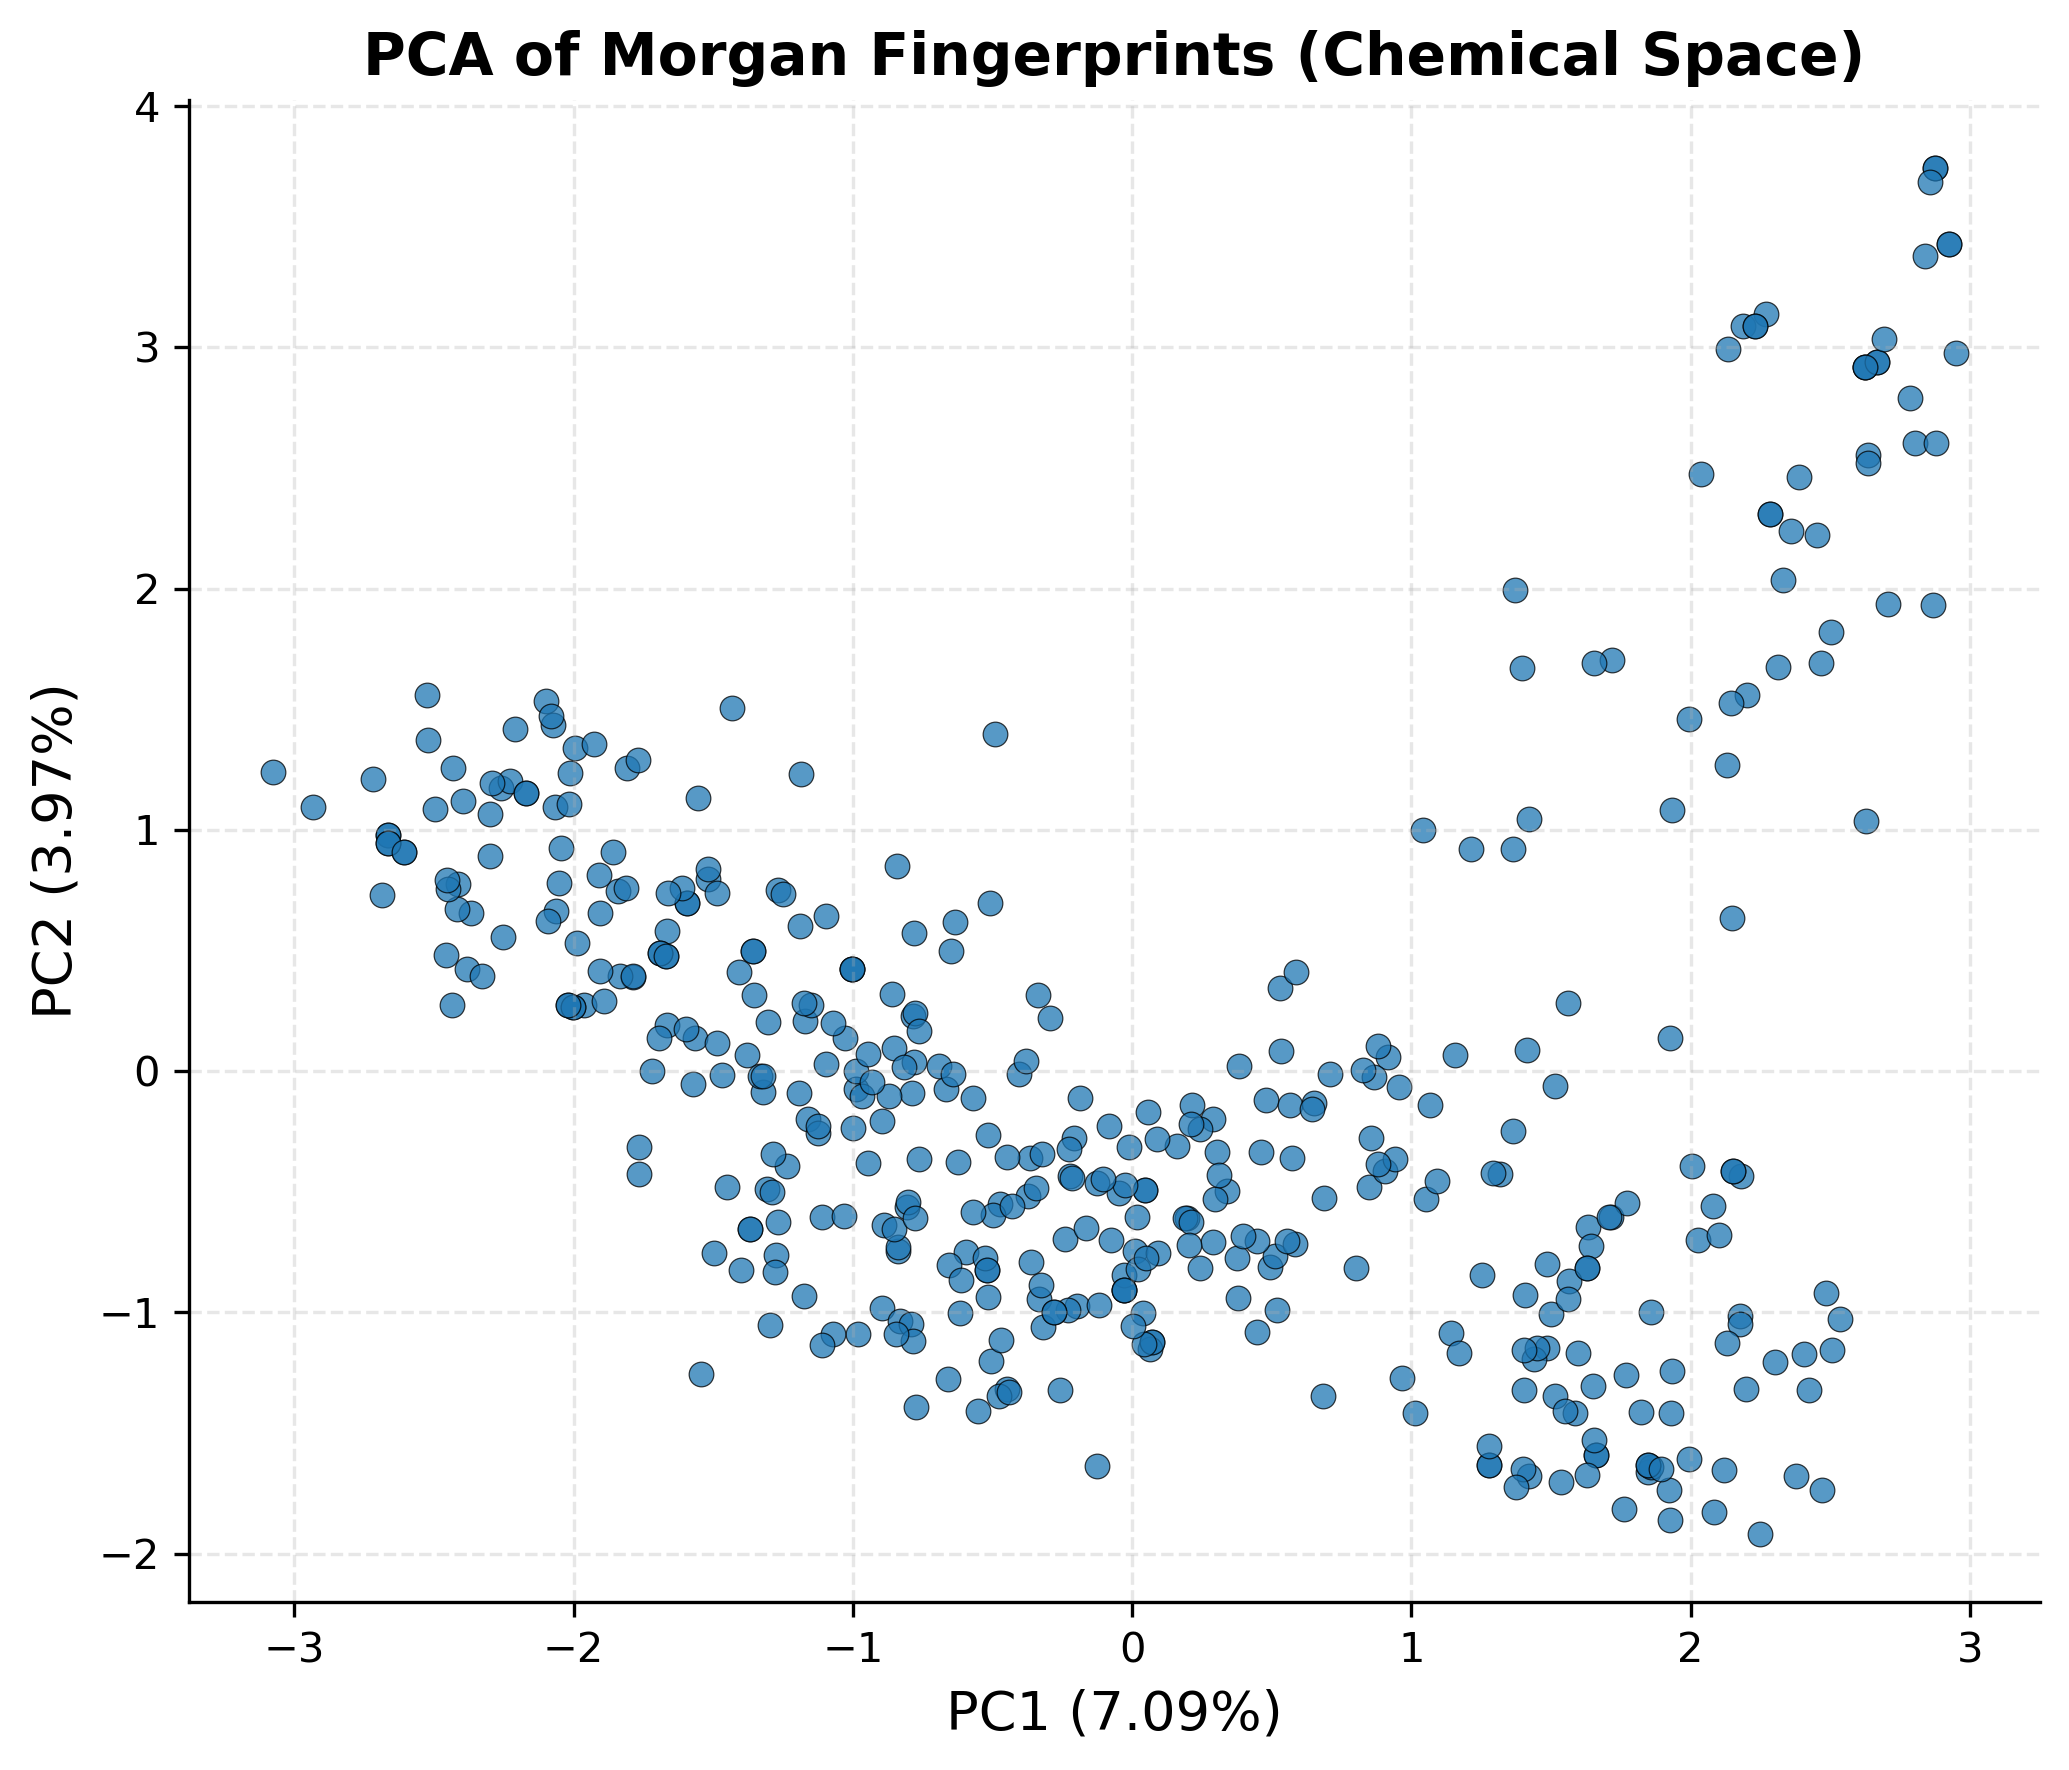

PCA figures saved successfully


In [11]:
# Create publication-ready PCA visualization

plt.figure(
    figsize=(7,6),
    dpi=300
)


# Plot ligand distribution in chemical space

plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    s=35,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.3
)


# Add explained variance to axes

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)",
    fontsize=13
)


plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)",
    fontsize=13
)


plt.title(
    "PCA of Morgan Fingerprints (Chemical Space)",
    fontsize=14,
    fontweight="bold"
)



# Remove unnecessary borders

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)



# Add light grid for readability

plt.grid(
    alpha=0.3,
    linestyle="--"
)


plt.tight_layout()



# Save-quality figures

pca_png = r"D:\FabI\PCA\PCA_Chemical_Space.png"

pca_tiff = r"D:\FabI\PCA\PCA_Chemical_Space.tiff"


plt.savefig(
    pca_png,
    dpi=300,
    bbox_inches="tight"
)


plt.savefig(
    pca_tiff,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print("PCA figures saved successfully")

### Step 5: K-means clustering using PCA features

Silhouette scores by k:
k=2: 0.4601
k=3: 0.5045
k=4: 0.5043
k=5: 0.4584
k=6: 0.4545
k=7: 0.4362
k=8: 0.4259
k=9: 0.4103
k=10: 0.3912
k=11: 0.3774
k=12: 0.3748
k=13: 0.3798
k=14: 0.3637
k=15: 0.3578


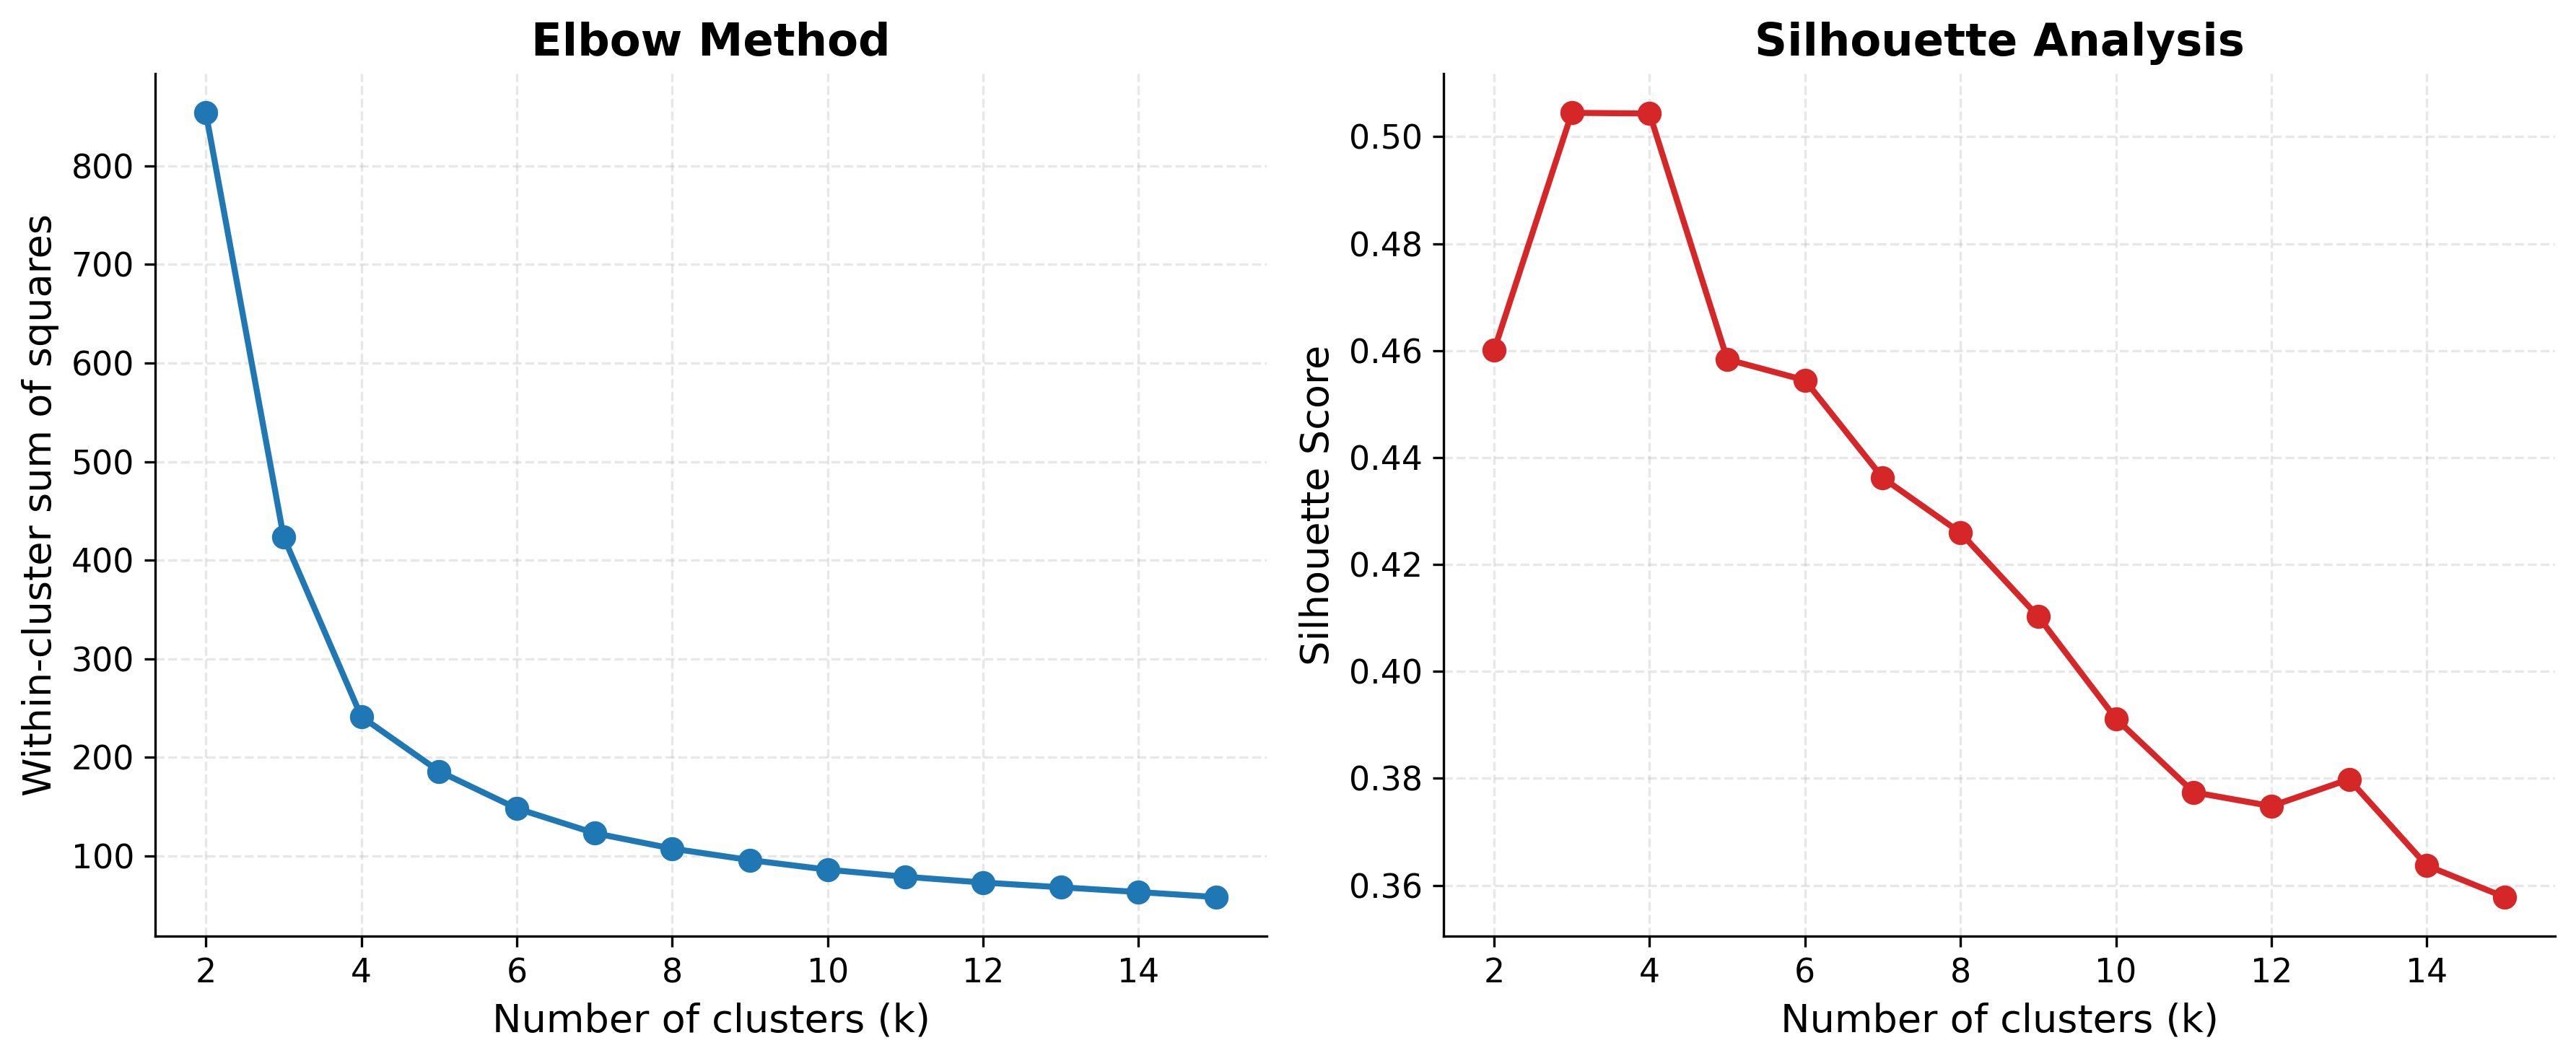


Saved:
D:\FabI\PCA\Kmeans_Elbow_Silhouette.png
D:\FabI\PCA\Kmeans_Elbow_Silhouette.tiff


In [30]:
# Purpose: Perform K-means clustering and determine optimal cluster number


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



# Use PCA components for clustering

# Change number of PCs if required

X_cluster = pca_result



# Define range of cluster numbers to test

k_range = range(2, 16)



# Store evaluation results

inertia_values = []

silhouette_values = []



# Test different k values

for k in k_range:

    # Apply K-means clustering

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )


    # Assign cluster labels

    labels = kmeans.fit_predict(
        X_cluster
    )


    # Calculate Elbow value

    inertia_values.append(
        kmeans.inertia_
    )


    # Calculate Silhouette score

    silhouette_values.append(
        silhouette_score(
            X_cluster,
            labels
        )
    )



# Print silhouette scores

print("==============================")
print("Silhouette scores by k:")
print("==============================")


for k, score in zip(
    k_range,
    silhouette_values
):

    print(
        f"k={k}: {score:.4f}"
    )



# Publication-ready Elbow and Silhouette plots

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5),
    dpi=300
)



# Elbow plot

axes[0].plot(
    list(k_range),
    inertia_values,
    marker="o",
    linewidth=2,
    markersize=7,
    color="#1f77b4"
)


axes[0].set_xlabel(
    "Number of clusters (k)",
    fontsize=13
)


axes[0].set_ylabel(
    "Within-cluster sum of squares",
    fontsize=13
)


axes[0].set_title(
    "Elbow Method",
    fontsize=15,
    fontweight="bold"
)



# Silhouette plot

axes[1].plot(
    list(k_range),
    silhouette_values,
    marker="o",
    linewidth=2,
    markersize=7,
    color="#d62728"
)


axes[1].set_xlabel(
    "Number of clusters (k)",
    fontsize=13
)


axes[1].set_ylabel(
    "Silhouette Score",
    fontsize=13
)


axes[1].set_title(
    "Silhouette Analysis",
    fontsize=15,
    fontweight="bold"
)



# Improve figure appearance

for ax in axes:

    ax.tick_params(
        labelsize=11
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        alpha=0.3,
        linestyle="--"
    )



plt.tight_layout()



# Save figures

save_png = r"D:\FabI\PCA\Kmeans_Elbow_Silhouette.png"

save_tiff = r"D:\FabI\PCA\Kmeans_Elbow_Silhouette.tiff"



plt.savefig(
    save_png,
    dpi=300,
    bbox_inches="tight"
)


plt.savefig(
    save_tiff,
    dpi=300,
    bbox_inches="tight"
)



plt.show()



print("\nSaved:")
print(save_png)
print(save_tiff)

### Step 5B: Final K-means clustering

In [31]:
# Purpose: Perform final K-means clustering with selected number of clusters


optimal_k = 4


kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)


# Assign cluster labels

cluster_labels = kmeans_final.fit_predict(
    X_cluster
)


print("==============================")
print("Final K-means clustering")
print("==============================")

print("Number of clusters:", optimal_k)



# Show cluster sizes

unique, counts = np.unique(
    cluster_labels,
    return_counts=True
)


print("\nCluster sizes:")


for cluster, count in zip(unique, counts):

    print(
        f"Cluster {cluster+1}: {count} ligands"
    )

Final K-means clustering
Number of clusters: 4

Cluster sizes:
Cluster 1: 111 ligands
Cluster 2: 98 ligands
Cluster 3: 50 ligands
Cluster 4: 174 ligands


### Step 6: Merge docking scores with K-means clusters

In [39]:

# Purpose: Create final cluster table for representative selection


# Your 433 ligand names used in PCA

final_ligands_df = pd.DataFrame({
    "Ligand": ligand_names
})



# Load original docking scores

score_file = r"D:\FabI\PCA\docking_scores.csv"

scores_df = pd.read_csv(score_file)



# Match only the 433 final ligands

cluster_score_df = final_ligands_df.merge(
    scores_df,
    on="Ligand",
    how="left"
)



print("Matched docking scores:")
print(
    cluster_score_df["Docking_Score"].notna().sum()
)



# Add cluster labels

cluster_score_df["Cluster"] = cluster_labels + 1



# Save

output_file = r"D:\FabI\PCA\Kmeans_cluster_docking_results.csv"


cluster_score_df.to_csv(
    output_file,
    index=False
)


print("Saved:")
print(output_file)

Matched docking scores:
433
Saved:
D:\FabI\PCA\Kmeans_cluster_docking_results.csv


### Step 7: Select Top 6 Docking Ligands per Cluster

In [40]:
# Purpose: Select best scoring compounds while keeping cluster diversity


# Load cluster results

cluster_file = r"D:\FabI\PCA\Kmeans_cluster_docking_results.csv"


cluster_score_df = pd.read_csv(
    cluster_file
)



# Sort docking scores
# More negative score = better binding

cluster_score_df = cluster_score_df.sort_values(
    by="Docking_Score",
    ascending=True
)



# Select top 6 compounds from each cluster

final_candidates = (
    cluster_score_df
    .groupby("Cluster")
    .head(6)
    .reset_index(drop=True)
)



print("==============================")
print("Final Selected Ligands")
print("==============================")


print(final_candidates)



print(
    "\nTotal ligands selected:",
    len(final_candidates)
)

Final Selected Ligands
                                               Ligand  Docking_Score  Cluster
0                   17-beta-Estradiol_glucuronide_out          -11.6        4
1                                      LTS0166628_out          -11.5        4
2                                       NPC472806_out          -11.5        2
3                                       NPC139976_out          -11.5        4
4                                       NPC253314_out          -11.3        4
5                                        NPC89225_out          -11.2        2
6                                     ZINC8762246_out          -11.0        2
7                                       NPC289227_out          -10.9        4
8                                       NPC488640_out          -10.8        2
9             24S-24-Methyl-25-dehydrocholesterol_out          -10.8        3
10                                      NPC489704_out          -10.7        2
11                                      N

In [41]:
# Purpose: Copy final selected ligand PDBQT files into one folder

# CHANGE THIS:
# Folder containing all 471 filtered ligand PDBQT files

ligand_pdbqt_dir = r"D:\FabI\PCA\filtered_pdbqt"


# CHANGE THIS:
# Folder for final 24 ligands

final_ligand_dir = r"D:\FabI\PCA\Final_24_PDBQT"


os.makedirs(
    final_ligand_dir,
    exist_ok=True
)



# Copy selected ligands

copied = 0
missing = 0


for ligand in final_candidates["Ligand"]:

    source = os.path.join(
        ligand_pdbqt_dir,
        ligand + ".pdbqt"
    )


    if os.path.exists(source):

        shutil.copy(
            source,
            final_ligand_dir
        )

        copied += 1

        print("Copied:", ligand)


    else:

        missing += 1

        print("Missing:", ligand)



print("\n==============================")
print("Copy Summary")
print("==============================")

print("Copied:", copied)
print("Missing:", missing)

print("Folder:")
print(final_ligand_dir)

Copied: 17-beta-Estradiol_glucuronide_out
Copied: LTS0166628_out
Copied: NPC472806_out
Copied: NPC139976_out
Copied: NPC253314_out
Copied: NPC89225_out
Copied: ZINC8762246_out
Copied: NPC289227_out
Copied: NPC488640_out
Copied: 24S-24-Methyl-25-dehydrocholesterol_out
Copied: NPC489704_out
Copied: NPC187302_out
Copied: S,E-Zearalenone_out
Copied: 31-nor-Lanosterol_out
Copied: abietadiene-diol_out
Copied: 24-Methyl-lanost-9_11-en-3-beta-ol_out
Copied: 31-nor-Lanost-8-en-3beta-ol_out
Copied: 4,14-Dimethylergosta-8,25-dien-3-ol_out
Copied: Lappaol_B_out
Copied: NPC5253_out
Copied: 3-hydroxy-2-{3-[(3-hydroxy-6-methylheptanoyl)oxy]-8-methylnonanamido}propanoic acid_out
Copied: Neosilyhermin A_out
Copied: Myricanol_out
Copied: ZINC2356582890_out

Copy Summary
Copied: 24
Missing: 0
Folder:
D:\FabI\PCA\Final_24_PDBQT


### Step 8: Generate protein-ligand complexes in PDBQT format


In [42]:
# Purpose: Combine protein and ligand PDBQT files


# CHANGE THIS:
protein_file = r"D:\FabI\Protein\receptor.pdbqt"


# CHANGE THIS:
ligand_dir = r"D:\FabI\PCA\Final_24_PDBQT"


# CHANGE THIS:
complex_dir = r"D:\FabI\PCA\Final_Complexes"



os.makedirs(
    complex_dir,
    exist_ok=True
)



# Read protein

with open(
    protein_file,
    "r"
) as f:

    protein_data = f.read()



total = 0



# Generate complexes

for ligand_file in glob.glob(
    os.path.join(
        ligand_dir,
        "*.pdbqt"
    )
):


    ligand_name = os.path.basename(
        ligand_file
    ).replace(
        ".pdbqt",
        ""
    )



    with open(
        ligand_file,
        "r"
    ) as f:

        ligand_data = f.read()



    complex_file = os.path.join(
        complex_dir,
        ligand_name + "_complex.pdbqt"
    )



    with open(
        complex_file,
        "w"
    ) as f:

        f.write(
            protein_data
        )

        f.write(
            ligand_data
        )



    total += 1

    print(
        "Created:",
        ligand_name
    )



print("\n==============================")
print("Complex generation complete")
print("==============================")

print("Total complexes:", total)
print("Saved folder:", complex_dir)

Created: 17-beta-Estradiol_glucuronide_out
Created: 24-Methyl-lanost-9_11-en-3-beta-ol_out
Created: 24S-24-Methyl-25-dehydrocholesterol_out
Created: 3-hydroxy-2-{3-[(3-hydroxy-6-methylheptanoyl)oxy]-8-methylnonanamido}propanoic acid_out
Created: 31-nor-Lanost-8-en-3beta-ol_out
Created: 31-nor-Lanosterol_out
Created: 4,14-Dimethylergosta-8,25-dien-3-ol_out
Created: abietadiene-diol_out


Created: Lappaol_B_out
Created: LTS0166628_out
Created: Myricanol_out
Created: Neosilyhermin A_out
Created: NPC139976_out
Created: NPC187302_out


Created: NPC253314_out
Created: NPC289227_out
Created: NPC472806_out
Created: NPC488640_out
Created: NPC489704_out


Created: NPC5253_out
Created: NPC89225_out
Created: S,E-Zearalenone_out
Created: ZINC2356582890_out
Created: ZINC8762246_out

Complex generation complete
Total complexes: 24
Saved folder: D:\FabI\PCA\Final_Complexes


### Step 9: Convert Protein–Ligand Complexes from PDBQT to PDB

In [43]:
# Purpose: Prepare final complexes for visualization and analysis


# CHANGE THIS:
# Folder containing complex PDBQT files

complex_pdbqt_dir = r"D:\FabI\PCA\Final_Complexes"



# CHANGE THIS:
# Output folder for PDB complexes

complex_pdb_dir = r"D:\FabI\PCA\Final_Complexes_PDB"



os.makedirs(
    complex_pdb_dir,
    exist_ok=True
)



converted = 0



# Convert each complex

for complex_file in glob.glob(
    os.path.join(
        complex_pdbqt_dir,
        "*.pdbqt"
    )
):


    complex_name = os.path.basename(
        complex_file
    ).replace(
        ".pdbqt",
        ""
    )



    # Read PDBQT

    molecule = next(
        pybel.readfile(
            "pdbqt",
            complex_file
        )
    )



    # Save as PDB

    output_file = os.path.join(
        complex_pdb_dir,
        complex_name + ".pdb"
    )



    molecule.write(
        "pdb",
        output_file,
        overwrite=True
    )



    converted += 1

    print(
        "Converted:",
        complex_name
    )



print("\n==============================")
print("Conversion complete")
print("==============================")

print("Total PDB complexes:", converted)

print("Saved folder:")
print(complex_pdb_dir)

Converted: 17-beta-Estradiol_glucuronide_out_complex
Converted: 24-Methyl-lanost-9_11-en-3-beta-ol_out_complex
Converted: 24S-24-Methyl-25-dehydrocholesterol_out_complex


Converted: 3-hydroxy-2-{3-[(3-hydroxy-6-methylheptanoyl)oxy]-8-methylnonanamido}propanoic acid_out_complex
Converted: 31-nor-Lanost-8-en-3beta-ol_out_complex


Converted: 31-nor-Lanosterol_out_complex
Converted: 4,14-Dimethylergosta-8,25-dien-3-ol_out_complex


Converted: abietadiene-diol_out_complex
Converted: Lappaol_B_out_complex


Converted: LTS0166628_out_complex
Converted: Myricanol_out_complex
Converted: Neosilyhermin A_out_complex
Converted: NPC139976_out_complex


Converted: NPC187302_out_complex
Converted: NPC253314_out_complex
Converted: NPC289227_out_complex


Converted: NPC472806_out_complex
Converted: NPC488640_out_complex
Converted: NPC489704_out_complex
Converted: NPC5253_out_complex
Converted: NPC89225_out_complex
Converted: S,E-Zearalenone_out_complex


Converted: ZINC2356582890_out_complex
Converted: ZINC8762246_out_complex

Conversion complete
Total PDB complexes: 24
Saved folder:
D:\FabI\PCA\Final_Complexes_PDB


### Convert Final pdbqt complexes to sdf for ligand efficiency

In [3]:
# Purpose: Convert final ligand PDBQT files to SDF


# CHANGE THIS:
input_dir = r"D:\FabI\PCA\Final_24_PDBQT"

# CHANGE THIS:
output_dir = r"D:\FabI\PCA\Final_complexes_SDF"


os.makedirs(output_dir, exist_ok=True)


for pdbqt_file in glob.glob(os.path.join(input_dir, "*.pdbqt")):

    mol = next(pybel.readfile("pdbqt", pdbqt_file))

    sdf_file = os.path.join(
        output_dir,
        os.path.basename(pdbqt_file).replace(".pdbqt", ".sdf")
    )

    mol.write("sdf", sdf_file, overwrite=True)

    print("Converted:", os.path.basename(sdf_file))


print("\nConversion completed.")

Converted: 17-beta-Estradiol_glucuronide_out.sdf
Converted: 24-Methyl-lanost-9_11-en-3-beta-ol_out.sdf
Converted: 24S-24-Methyl-25-dehydrocholesterol_out.sdf
Converted: 3-hydroxy-2-{3-[(3-hydroxy-6-methylheptanoyl)oxy]-8-methylnonanamido}propanoic acid_out.sdf
Converted: 31-nor-Lanost-8-en-3beta-ol_out.sdf
Converted: 31-nor-Lanosterol_out.sdf
Converted: 4,14-Dimethylergosta-8,25-dien-3-ol_out.sdf
Converted: abietadiene-diol_out.sdf
Converted: Lappaol_B_out.sdf
Converted: LTS0166628_out.sdf
Converted: Myricanol_out.sdf
Converted: Neosilyhermin A_out.sdf
Converted: NPC139976_out.sdf
Converted: NPC187302_out.sdf
Converted: NPC253314_out.sdf
Converted: NPC289227_out.sdf
Converted: NPC472806_out.sdf
Converted: NPC488640_out.sdf
Converted: NPC489704_out.sdf
Converted: NPC5253_out.sdf
Converted: NPC89225_out.sdf
Converted: S,E-Zearalenone_out.sdf
Converted: ZINC2356582890_out.sdf
Converted: ZINC8762246_out.sdf

Conversion completed.


### Step10: Ligand Efficiency Score

In [12]:
# Purpose: Calculate ligand efficiency for final selected ligands

# CHANGE THIS:
# Final 24 ligand SDF folder

sdf_dir = r"D:\FabI\PCA\Final_complexes_SDF"



# CHANGE THIS:
# Cluster+docking score file

score_file = r"D:\FabI\PCA\Kmeans_cluster_docking_results.csv"



# Load docking results

ligand_scores = pd.read_csv(
    score_file
)



# Store results

LE_results = []



# Calculate LE

for sdf_file in glob.glob(
    os.path.join(
        sdf_dir,
        "*.sdf"
    )
):

    ligand_name = os.path.basename(
        sdf_file
    ).replace(
        ".sdf",
        ""
    )



    # Read ligand

    mol = Chem.MolFromMolFile(
        sdf_file
    )


    if mol is None:
        print("Failed:", ligand_name)
        continue



    # Heavy atom count

    heavy_atoms = mol.GetNumHeavyAtoms()



    # Get docking score

    score = ligand_scores.loc[
        ligand_scores["Ligand"] == ligand_name,
        "Docking_Score"
    ]



    if len(score) == 0:

        print(
            "Score not found:",
            ligand_name
        )

        continue



    score = score.values[0]



    # Ligand efficiency

    LE = abs(score) / heavy_atoms



    LE_results.append(
        [
            ligand_name,
            score,
            heavy_atoms,
            LE
        ]
    )



# Create dataframe

LE_df = pd.DataFrame(
    LE_results,
    columns=[
        "Ligand",
        "Docking_Score",
        "Heavy_Atoms",
        "Ligand_Efficiency"
    ]
)



# Sort highest efficiency first

LE_df = LE_df.sort_values(
    by="Ligand_Efficiency",
    ascending=False
)



print("==============================")
print("Ligand Efficiency Results")
print("==============================")

print(LE_df)



print(
    "\nTotal ligands analyzed:",
    len(LE_df)
)

NameError: name 'LE_df' is not defined

0    1,1-dichloro-5-(3-hydroxy-5-methoxyphenyl)pent...
1                             1,2-Humulene_epoxide_out
2    1,5-Epoxy-3-hydroxy-1-4-hydroxy-3,5-dimethoxyp...
3    1,8-bis(acetyloxy)-2,4-dimethyloctan-3-yl 2-(a...
4     1-(4-hydroxy-3-methoxyphenyl)octane-3,5-diol_out
5                            1-Methoxyphaseollidin_out
6         1-[4-(butan-2-yl)phenyl]propane-1,2-diol_out
7                       11-Cycloneren-3,7,10-Triol_out
8                                        122411792_out
9                                         13341191_out
Name: Ligand, dtype: object